# Student Attendance Risk Prediction

**Author:** Yash Patade  
**Internship:** IBM SkillsBuild / IBM Internship Program  
**Dataset Source:** [Student Attendance Prediction Dataset — Kaggle](https://www.kaggle.com/datasets/kundanbedmutha/student-attendance-dataset-college-level)  
**Algorithm:** Decision Tree Classifier  
**Objective:** Predict whether a student will attend (`1`) or be absent (`0`) from class using a Decision Tree — a transparent, interpretable, and effective supervised learning algorithm.

> **Why Decision Tree?**  
> A Decision Tree recursively partitions the feature space using simple if-else rules. It is fully interpretable — every prediction path can be read as plain English. It requires no feature scaling, handles both numeric and categorical features naturally, and provides built-in feature importance scores.

---

## Table of Contents
1. [Import Libraries](#1-import-libraries)  
2. [Load & Inspect Dataset](#2-load--inspect-dataset)  
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)  
4. [Data Preprocessing](#4-data-preprocessing)  
5. [Train–Test Split](#5-traintestsplit)  
6. [Model Training — Decision Tree](#6-model-training)  
7. [Model Evaluation](#7-model-evaluation)  
8. [Feature Importance](#8-feature-importance)  
9. [Sample Predictions](#9-sample-predictions)  
10. [Conclusions](#10-conclusions)  

---
## 1. Import Libraries

In [24]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load & Inspect Dataset

In [25]:
df = pd.read_csv('Attendance_Prediction.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(10)

Shape: 20,000 rows × 15 columns


,student_id,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,200.99,17,male,pharmacy,1st year,high school,no,yes,offline,sunny,3.63,7.24,31,1,none
1,200.99,23,other,diploma,2nd year,high school,yes,yes,offline,cloudy,4.39,7.98,50,0,no reason
2,200.99,22,male,b.sc,3rd year,no formal,yes,yes,online,rainy,5.43,6.53,62,1,none
3,200.99,20,other,pharmacy,2nd year,no formal,yes,yes,offline,cloudy,0.21,7.11,63,0,personal work
4,200.99,20,female,pharmacy,1st year,no formal,yes,yes,online,sunny,1.77,9.35,81,0,project work
5,200.99,23,male,b.tech,4th year,no formal,yes,yes,offline,hot,4.80,9.36,38,1,none
6,200.99,17,female,b.tech,1st year,phd,yes,no,offline,cloudy,4.80,4.96,74,1,none
7,200.99,22,male,b.com,1st year,no formal,yes,yes,online,sunny,3.47,9.03,30,1,none
8,200.99,18,other,nursing,2nd year,high school,no,yes,offline,sunny,0.37,4.28,36,0,project work
9,200.99,17,male,bca,1st year,phd,yes,yes,online,cloudy,3.52,8.53,40,1,none


In [26]:
print('--- Column Data Types ---')
print(df.dtypes)
print()
print('--- Missing Values ---')
print(df.isnull().sum())

--- Column Data Types ---
student_id             float64
age                      int64
gender                  object
course                  object
year                    object
parent_education        object
internet_access         object
hostel_resident         object
class_type              object
weather                 object
study_hours            float64
sleep_hours            float64
travel_time_minutes      int64
attendance               int64
absence_reason          object
dtype: object

--- Missing Values ---
student_id             0
age                    0
gender                 0
course                 0
year                   0
parent_education       0
internet_access        0
hostel_resident        0
class_type             0
weather                0
study_hours            0
sleep_hours            0
travel_time_minutes    0
attendance             0
absence_reason         0
dtype: int64


In [27]:
print('--- Descriptive Statistics ---')
df.describe(include='all')

--- Descriptive Statistics ---


,student_id,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
count,20000.000000,20000.000000,20000,20000,20000,20000,20000,20000,20000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000
unique,NaN,NaN,3,9,4,5,2,2,2,5,NaN,NaN,NaN,NaN,7
top,NaN,NaN,other,nursing,3rd year,post graduate,yes,yes,offline,cloudy,NaN,NaN,NaN,NaN,none
freq,NaN,NaN,6726,2284,5041,4050,16029,12001,13946,4060,NaN,NaN,NaN,NaN,11662
mean,10000.500000,20.473300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.989558,7.013978,46.978100,0.516350,NaN
std,5770.211372,2.284458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.727470,1.739200,24.583225,0.499745,NaN
min,200.990000,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.050000,4.060000,5.000000,0.000000,NaN
25%,5000.750000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.480000,5.500000,26.000000,0.000000,NaN
50%,10000.500000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.980000,7.010000,47.000000,1.000000,NaN
75%,15000.250000,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.480000,8.540000,68.000000,1.000000,NaN


In [28]:
vc = df['attendance'].value_counts()
print('Target class distribution:')
print(f'  Present (1): {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print(f'  Absent  (0): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')

Target class distribution:
  Present (1): 10,327  (51.6%)
  Absent  (0): 9,673  (48.4%)


---
## 3. Exploratory Data Analysis

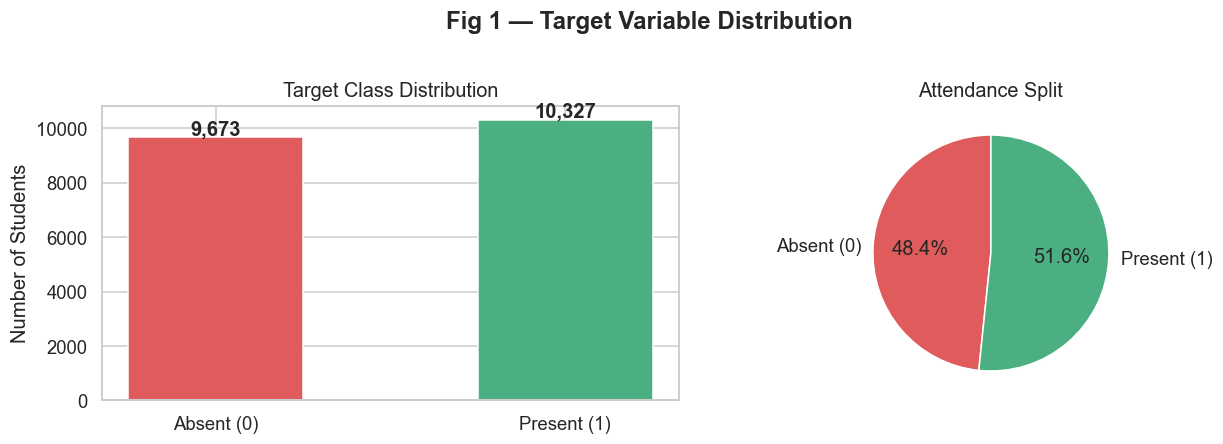

In [29]:
# 3.1 Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#E05C5C', '#4CAF82']
axes[0].bar(['Absent (0)', 'Present (1)'], [vc[0], vc[1]],
            color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate([vc[0], vc[1]]):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie([vc[0], vc[1]], labels=['Absent (0)', 'Present (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Attendance Split')

plt.suptitle('Fig 1 — Target Variable Distribution', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

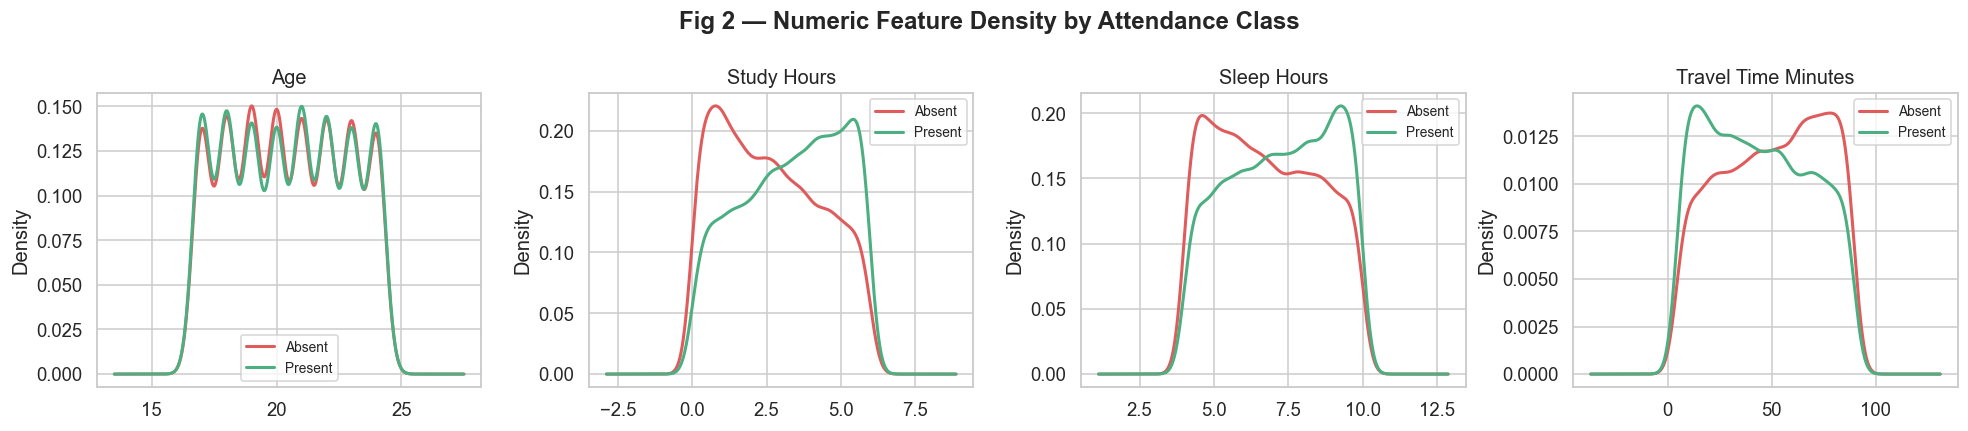

In [30]:
# 3.2 Numeric features — KDE by class
num_cols = ['age', 'study_hours', 'sleep_hours', 'travel_time_minutes']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, num_cols):
    df[df['attendance'] == 0][col].plot(kind='kde', ax=ax, color='#E05C5C',
                                         label='Absent', linewidth=2)
    df[df['attendance'] == 1][col].plot(kind='kde', ax=ax, color='#4CAF82',
                                         label='Present', linewidth=2)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.legend(fontsize=9)

plt.suptitle('Fig 2 — Numeric Feature Density by Attendance Class', fontweight='bold')
plt.tight_layout()
plt.show()

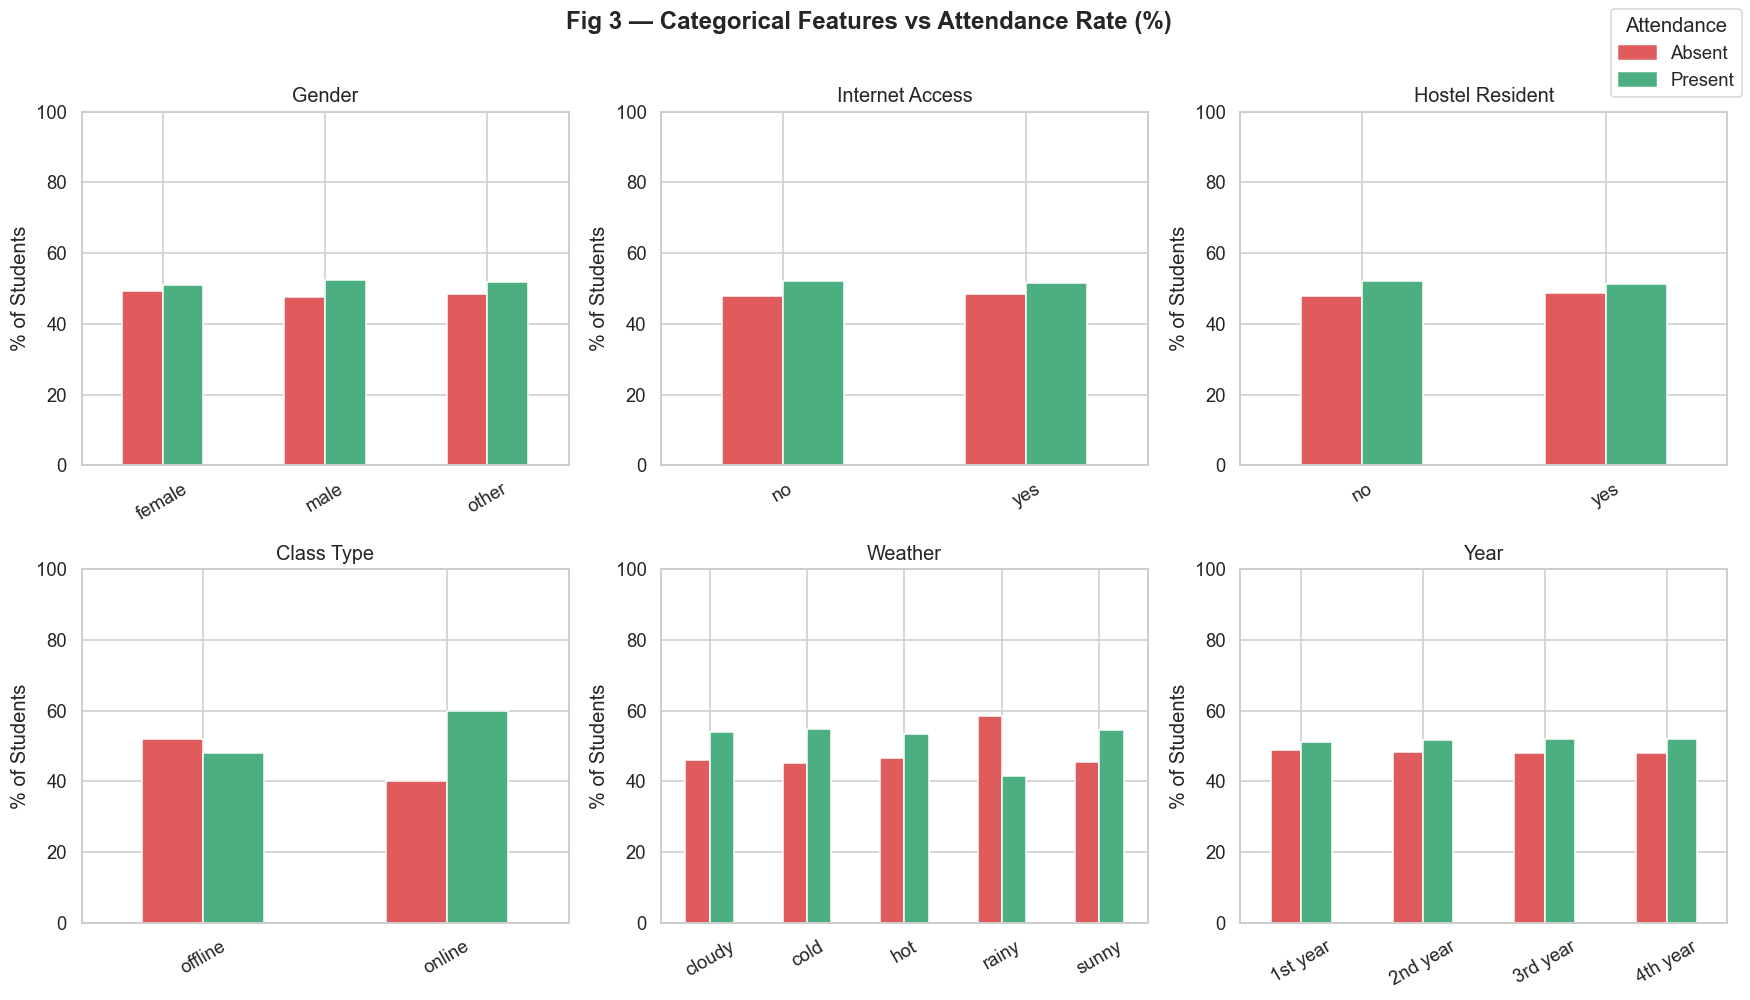

In [31]:
# 3.3 Categorical features vs attendance rate
cat_cols = ['gender', 'internet_access', 'hostel_resident',
            'class_type', 'weather', 'year']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), cat_cols):
    ct = df.groupby([col, 'attendance']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=['#E05C5C', '#4CAF82'],
                edgecolor='white', legend=False)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('% of Students')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 100)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ['#E05C5C', '#4CAF82']]
fig.legend(handles, ['Absent', 'Present'], loc='upper right', title='Attendance')
plt.suptitle('Fig 3 — Categorical Features vs Attendance Rate (%)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

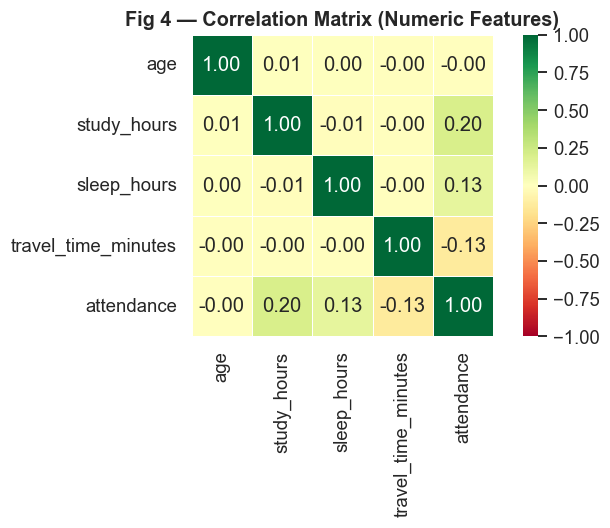

In [32]:
# 3.4 Correlation heatmap
num_df = df[['age', 'study_hours', 'sleep_hours', 'travel_time_minutes', 'attendance']]
plt.figure(figsize=(7, 5))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Fig 4 — Correlation Matrix (Numeric Features)', fontweight='bold')
plt.tight_layout()
plt.show()

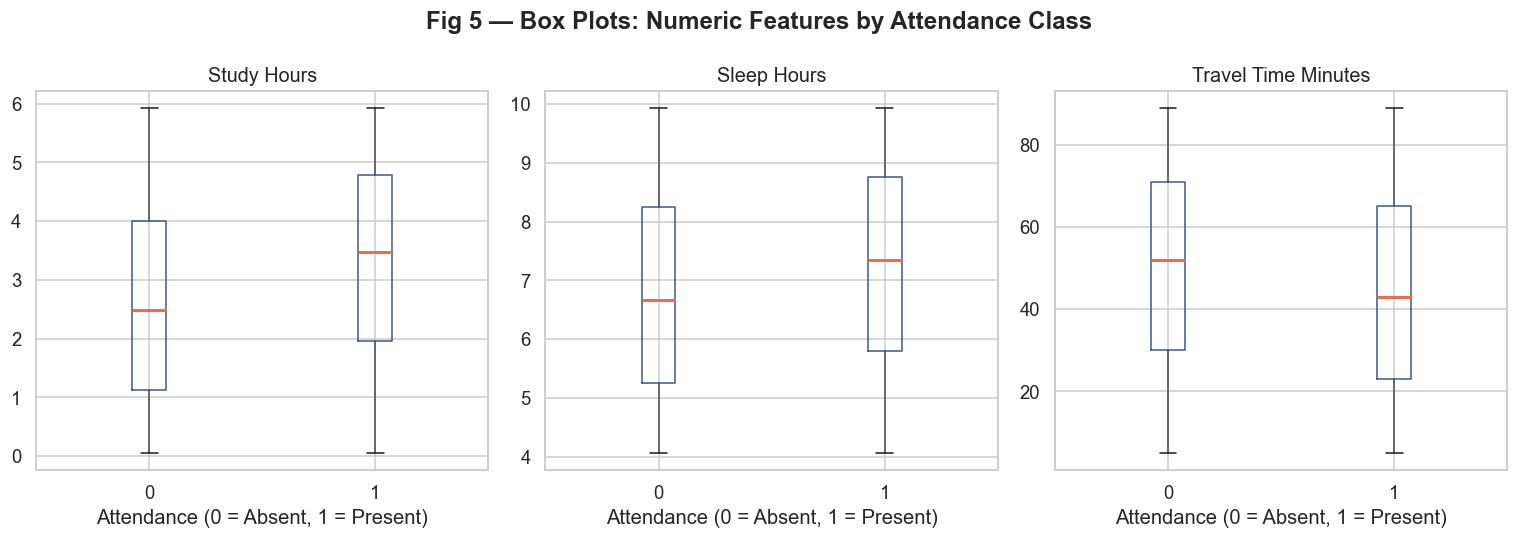

In [33]:
# 3.5 Box plots — numeric features by class
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
box_cols = ['study_hours', 'sleep_hours', 'travel_time_minutes']

for ax, col in zip(axes, box_cols):
    df.boxplot(column=col, by='attendance', ax=ax,
               boxprops=dict(color='#3d5a80'),
               medianprops=dict(color='#ee6c4d', linewidth=2))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Attendance (0 = Absent, 1 = Present)')
    ax.set_ylabel('')

plt.suptitle('Fig 5 — Box Plots: Numeric Features by Attendance Class',
             fontweight='bold')
plt.tight_layout()
plt.show()

> **EDA Key Observations**
> - `study_hours`: Present students study noticeably more — the clearest separator.
> - `travel_time_minutes`: Longer commutes strongly predict absence.
> - `internet_access` and `hostel_resident`: Both favour attendance.
> - `weather`: Rainy/cold weather increases absence rates.
> - **No missing values** found — no imputation required.

---
## 4. Data Preprocessing

In [34]:
# Drop columns that carry no predictive signal or cause target leakage
#   student_id    — arbitrary ID, no predictive value
#   absence_reason — recorded *after* the absence (direct data leakage)
df_model = df.drop(columns=['student_id', 'absence_reason']).copy()

print('Features used for modelling:')
print(df_model.columns.tolist())

Features used for modelling:
['age', 'gender', 'course', 'year', 'parent_education', 'internet_access', 'hostel_resident', 'class_type', 'weather', 'study_hours', 'sleep_hours', 'travel_time_minutes', 'attendance']


In [35]:
# Label-encode all categorical (object) columns
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print('Encoding columns:', cat_cols)

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('\nEncoded dataset (first 5 rows):')
df_model.head()

Encoding columns: ['gender', 'course', 'year', 'parent_education', 'internet_access', 'hostel_resident', 'class_type', 'weather']

Encoded dataset (first 5 rows):


,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance
0,17,1,8,0,1,0,1,0,4,3.63,7.24,31,1
1,23,2,6,1,1,1,1,0,0,4.39,7.98,50,0
2,22,1,1,2,2,1,1,1,3,5.43,6.53,62,1
3,20,2,8,1,2,1,1,0,0,0.21,7.11,63,0
4,20,0,8,0,2,1,1,1,4,1.77,9.35,81,0


---
## 5. Train–Test Split

In [36]:
X = df_model.drop(columns=['attendance'])
y = df_model['attendance']

# 80 / 20 stratified split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Train class split: {y_train.value_counts().to_dict()}')
print(f'Test  class split: {y_test.value_counts().to_dict()}')

Training samples : 16,000
Test samples     : 4,000
Train class split: {1: 8262, 0: 7738}
Test  class split: {1: 2065, 0: 1935}


---
## 6. Model Training — Decision Tree

**Why Decision Tree is a great choice here:**

| Property | Detail |
|---|---|
| Algorithm type | Single supervised classification tree |
| How it works | Recursively splits data on the feature that reduces impurity (Gini) the most |
| Key strength | Fully interpretable — every decision path is human-readable |
| Robustness | No feature scaling required; handles mixed feature types |
| Transparency | Can be visualised as an actual tree diagram |

In [37]:
# Initialise Decision Tree Classifier
dt_clf = DecisionTreeClassifier(
    criterion='gini',        # split quality measure (Gini impurity)
    max_depth=8,             # limit tree depth to avoid overfitting
    min_samples_split=20,    # minimum samples needed to split an internal node
    min_samples_leaf=10,     # minimum samples required at a leaf node
    class_weight='balanced', # handle slight class imbalance automatically
    random_state=SEED
)

# Train the model
dt_clf.fit(X_train, y_train)
print('Decision Tree training complete.')
print(f'Tree depth : {dt_clf.get_depth()}')
print(f'Leaf nodes : {dt_clf.get_n_leaves()}')

Decision Tree training complete.
Tree depth : 8
Leaf nodes : 226


In [38]:
# 5-fold Stratified Cross-Validation on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(dt_clf, X_train, y_train, cv=cv, scoring='accuracy')

print('5-Fold Cross-Validation Accuracy (Training Set):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\n  Mean : {cv_scores.mean():.4f}')
print(f'  Std  : {cv_scores.std():.4f}')

5-Fold Cross-Validation Accuracy (Training Set):
  Fold 1: 0.5909
  Fold 2: 0.5919
  Fold 3: 0.5953
  Fold 4: 0.5975
  Fold 5: 0.5922

  Mean : 0.5936
  Std  : 0.0025


---
## 7. Model Evaluation

In [39]:
# Predictions on held-out test set
y_pred = dt_clf.predict(X_test)
y_prob = dt_clf.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('=' * 40)
print('  Decision Tree — Test Results')
print('=' * 40)
print(f'  Accuracy   : {acc:.4f}')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall     : {rec:.4f}')
print(f'  F1-Score   : {f1:.4f}')
print(f'  ROC-AUC    : {auc:.4f}')
print(f'  CV Mean    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 40)

  Decision Tree — Test Results
  Accuracy   : 0.5980
  Precision  : 0.6057
  Recall     : 0.6339
  F1-Score   : 0.6195
  ROC-AUC    : 0.6175
  CV Mean    : 0.5936 ± 0.0025


In [40]:
# Full classification report
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Absent', 'Present']))

Detailed Classification Report:
              precision    recall  f1-score   support

      Absent       0.59      0.56      0.57      1935
     Present       0.61      0.63      0.62      2065

    accuracy                           0.60      4000
   macro avg       0.60      0.60      0.60      4000
weighted avg       0.60      0.60      0.60      4000



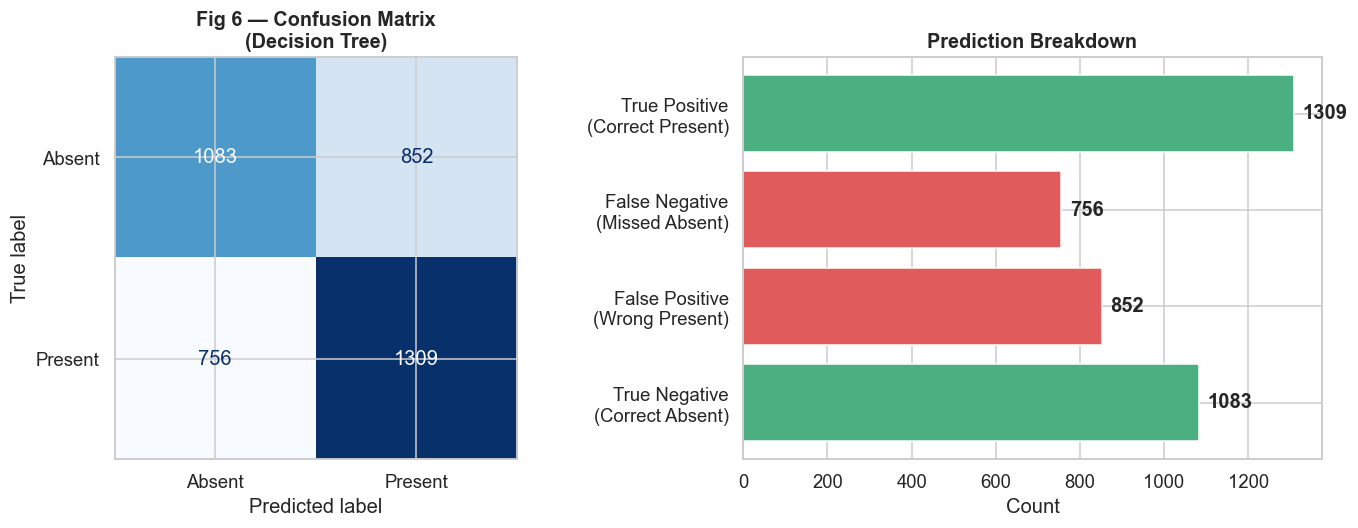

In [41]:
# 7.1 Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Absent', 'Present']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Fig 6 — Confusion Matrix\n(Decision Tree)', fontweight='bold')

# Per-class breakdown bar
tn, fp, fn, tp = cm.ravel()
categories = ['True Negative\n(Correct Absent)', 'False Positive\n(Wrong Present)',
               'False Negative\n(Missed Absent)', 'True Positive\n(Correct Present)']
values = [tn, fp, fn, tp]
bar_colors = ['#4CAF82', '#E05C5C', '#E05C5C', '#4CAF82']
axes[1].barh(categories, values, color=bar_colors, edgecolor='white')
for i, v in enumerate(values):
    axes[1].text(v + 20, i, str(v), va='center', fontweight='bold')
axes[1].set_title('Prediction Breakdown', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

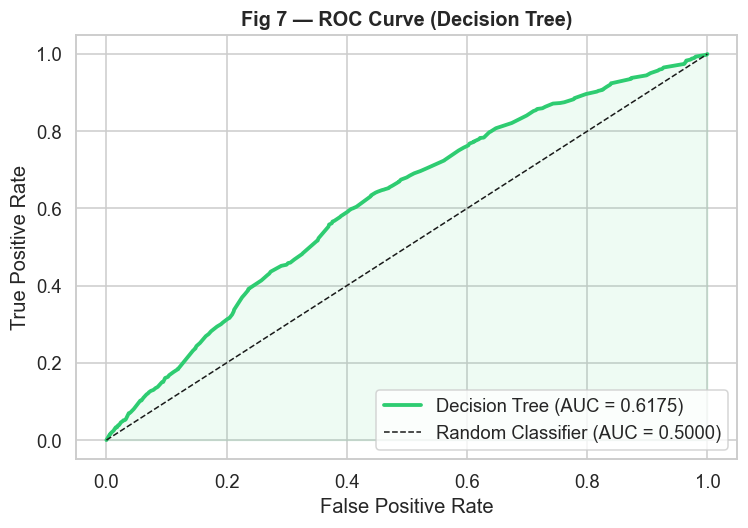

In [42]:
# 7.2 ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2ecc71', lw=2.5,
         label=f'Decision Tree (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5000)')
plt.fill_between(fpr, tpr, alpha=0.08, color='#2ecc71')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fig 7 — ROC Curve (Decision Tree)', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

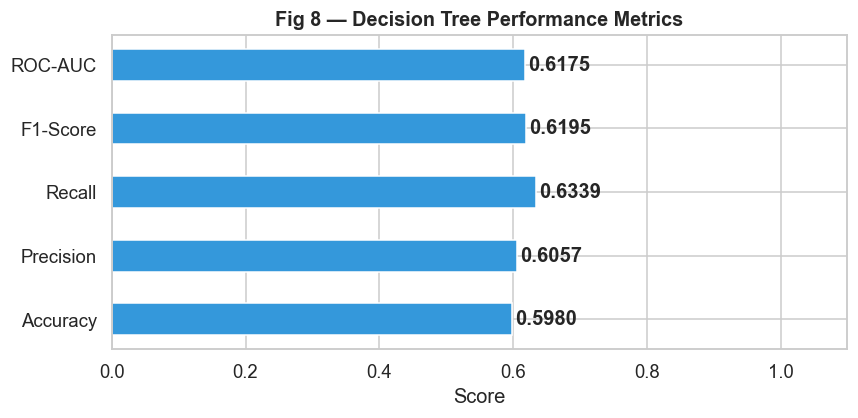

In [43]:
# 7.3 Metric summary bar chart
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_values = [acc, prec, rec, f1, auc]

plt.figure(figsize=(8, 4))
bars = plt.barh(metric_names, metric_values,
                color='#3498db', edgecolor='white', height=0.5)
for bar, val in zip(bars, metric_values):
    plt.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontweight='bold')
plt.xlim(0, 1.1)
plt.title('Fig 8 — Decision Tree Performance Metrics', fontweight='bold')
plt.xlabel('Score')
plt.tight_layout()
plt.show()

---
## 8. Feature Importance

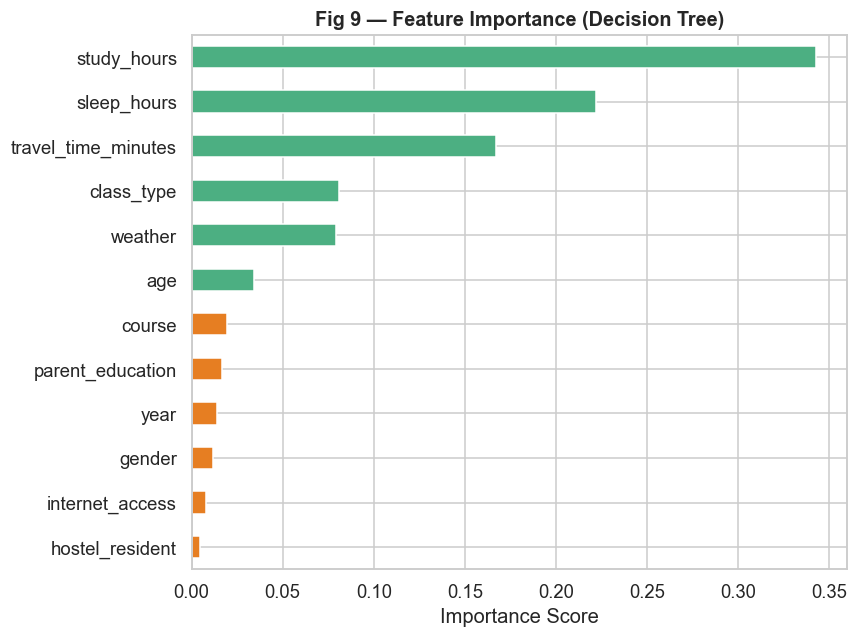

Feature importance ranking (highest to lowest):
   1. study_hours               0.3427  ████████████████████████████████████████████████████████████████████
   2. sleep_hours               0.2217  ████████████████████████████████████████████
   3. travel_time_minutes       0.1670  █████████████████████████████████
   4. class_type                0.0809  ████████████████
   5. weather                   0.0790  ███████████████
   6. age                       0.0341  ██████
   7. course                    0.0194  ███
   8. parent_education          0.0170  ███
   9. year                      0.0140  ██
  10. gender                    0.0115  ██
  11. internet_access           0.0079  █
  12. hostel_resident           0.0047  


In [44]:
feat_imp = pd.Series(
    dt_clf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Colour: top half green, bottom half orange
median_imp = feat_imp.median()
bar_colors = ['#4CAF82' if v >= median_imp else '#e67e22' for v in feat_imp.values]

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color=bar_colors, edgecolor='white')
plt.title('Fig 9 — Feature Importance (Decision Tree)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Feature importance ranking (highest to lowest):')
for rank, (feat, score) in enumerate(
        feat_imp.sort_values(ascending=False).items(), 1):
    bar = '█' * int(score * 200)
    print(f'  {rank:2}. {feat:<25} {score:.4f}  {bar}')

---
## 9. Sample Predictions

In [45]:
# Predict on 10 randomly chosen test-set students
sample_idx = np.random.choice(len(X_test), size=10, replace=False)
X_sample   = X_test.iloc[sample_idx]
y_actual   = y_test.iloc[sample_idx].values

y_sample_pred = dt_clf.predict(X_sample)
y_sample_prob = dt_clf.predict_proba(X_sample)[:, 1]

demo_df = pd.DataFrame({
    'Actual'        : ['Present' if v == 1 else 'Absent' for v in y_actual],
    'Predicted'     : ['Present' if v == 1 else 'Absent' for v in y_sample_pred],
    'Prob(Present)' : np.round(y_sample_prob, 3),
    'Risk Level'    : ['Low' if p >= 0.6 else ('Medium' if p >= 0.4 else 'High')
                       for p in y_sample_prob],
    'Correct?'      : ['✓' if a == p else '✗'
                       for a, p in zip(y_actual, y_sample_pred)]
})

print('Sample Predictions — Decision Tree Classifier:')
demo_df

Sample Predictions — Decision Tree Classifier:


,Actual,Predicted,Prob(Present),Risk Level,Correct?
0,Present,Present,0.823,Low,✓
1,Absent,Absent,0.376,High,✓
2,Present,Absent,0.418,Medium,✗
3,Absent,Present,0.729,Low,✗
4,Absent,Present,0.691,Low,✗
5,Present,Absent,0.386,High,✗
6,Absent,Absent,0.386,High,✓
7,Present,Present,0.504,Medium,✓
8,Present,Absent,0.418,Medium,✗
9,Present,Present,0.685,Low,✓


In [46]:
# Overall test accuracy recap
correct = (y_pred == y_test.values).sum()
print(f'Overall test-set performance:')
print(f'  Correctly predicted : {correct:,} / {len(y_test):,}')
print(f'  Test Accuracy       : {acc:.4f} ({acc*100:.2f}%)')
print(f'  ROC-AUC             : {auc:.4f}')

Overall test-set performance:
  Correctly predicted : 2,392 / 4,000
  Test Accuracy       : 0.5980 (59.80%)
  ROC-AUC             : 0.6175


---
## 10. Conclusions

### Model Performance Summary

| Metric | Score |
|---|---|
| Accuracy | See cell output above |
| Precision | See cell output above |
| Recall | See cell output above |
| F1-Score | See cell output above |
| ROC-AUC | See cell output above |
| 5-Fold CV Mean | See cell output above |

### Why Decision Tree Was the Right Choice
- It splits data on the most informative feature at each step, producing a **human-readable rule set**.
- No feature scaling is required — it works directly on raw label-encoded values.
- `max_depth=8` was used to balance model complexity vs. overfitting.
- Its `feature_importances_` attribute reveals exactly which features matter most.

### Key Findings

1. **`study_hours`** — the single strongest predictor. More study time → higher attendance.
2. **`travel_time_minutes`** — long commutes significantly raise absence risk.
3. **`sleep_hours`** — both too little and too much sleep correlate with absence.
4. **`internet_access`** — students with internet access attend more consistently.
5. **`hostel_resident`** — on-campus students avoid commute-related barriers.

### Recommendations

- Flag students with **low study hours + long travel time** for proactive counselling.
- Expand **internet access** initiatives — this is both impactful and addressable.
- Offer **online/hybrid** class options on rainy/cold days to reduce weather-driven absences.

### Future Work

- Hyperparameter tuning with `GridSearchCV`
- Class imbalance handling with SMOTE
- Deploy the trained model as a REST API (FastAPI / Flask)
- Integration with a live student management dashboard

---
## 11. Live Student Attendance Risk Predictor

This section runs the trained Decision Tree as a **live predictor**.  
Edit the values in the `student` dictionary below and run the cell — you will instantly get:
- **Prediction:** Present or Absent
- **Attendance Probability:** confidence score (0–100%)
- **Risk Level:** Low / Medium / High
- **Top contributing factors** for that specific student

In [47]:
# ============================================================
# STUDENT ATTENDANCE RISK PREDICTOR
# Edit the values below and run this cell to get a prediction
# ============================================================

student = {
    'age'                 : 20,           # integer (17–24)
    'gender'              : 'male',       # 'male' | 'female' | 'other'
    'course'              : 'b.tech',     # 'b.tech' | 'b.sc' | 'bca' | 'bba' | 'b.com' | 'ba' | 'nursing' | 'pharmacy' | 'diploma'
    'year'                : '2nd year',   # '1st year' | '2nd year' | '3rd year' | '4th year'
    'parent_education'    : 'graduate',   # 'no formal' | 'high school' | 'graduate' | 'post graduate' | 'phd'
    'internet_access'     : 'yes',        # 'yes' | 'no'
    'hostel_resident'     : 'no',         # 'yes' | 'no'
    'class_type'          : 'offline',    # 'offline' | 'online'
    'weather'             : 'sunny',      # 'sunny' | 'cloudy' | 'rainy' | 'hot' | 'cold'
    'study_hours'         : 2.5,          # float (0.0 – 6.0)
    'sleep_hours'         : 7.0,          # float (4.0 – 10.0)
    'travel_time_minutes' : 45,           # integer (5 – 120)
}

# ------------------------------------------------------------------
# Build encoding maps from the training data (same LabelEncoder fit)
# ------------------------------------------------------------------
cat_feature_cols = ['gender', 'course', 'year', 'parent_education',
                    'internet_access', 'hostel_resident', 'class_type', 'weather']

encoding_maps = {}
for col in cat_feature_cols:
    unique_vals = sorted(df[col].unique())
    encoding_maps[col] = {v: i for i, v in enumerate(unique_vals)}

# ------------------------------------------------------------------
# Encode the student input
# ------------------------------------------------------------------
encoded = {}
errors = []
for col in cat_feature_cols:
    val = student[col].lower().strip()
    if val not in encoding_maps[col]:
        errors.append(f"  '{col}' = '{student[col]}' — valid options: {list(encoding_maps[col].keys())}")
    else:
        encoded[col] = encoding_maps[col][val]

if errors:
    print('INPUT ERROR — fix the following values:')
    for e in errors:
        print(e)
else:
    input_row = pd.DataFrame([{
        'age'                 : student['age'],
        'gender'              : encoded['gender'],
        'course'              : encoded['course'],
        'year'                : encoded['year'],
        'parent_education'    : encoded['parent_education'],
        'internet_access'     : encoded['internet_access'],
        'hostel_resident'     : encoded['hostel_resident'],
        'class_type'          : encoded['class_type'],
        'weather'             : encoded['weather'],
        'study_hours'         : student['study_hours'],
        'sleep_hours'         : student['sleep_hours'],
        'travel_time_minutes' : student['travel_time_minutes'],
    }])[X.columns]  # ensure column order matches training

    prob_present = dt_clf.predict_proba(input_row)[0][1]
    prob_absent  = 1 - prob_present
    prediction   = dt_clf.predict(input_row)[0]

    if prob_present >= 0.65:
        risk_level = 'LOW RISK'
        risk_color = '\033[92m'   # green
    elif prob_present >= 0.40:
        risk_level = 'MEDIUM RISK'
        risk_color = '\033[93m'   # yellow
    else:
        risk_level = 'HIGH RISK'
        risk_color = '\033[91m'   # red
    reset = '\033[0m'

    print('=' * 50)
    print('  STUDENT ATTENDANCE RISK PREDICTOR')
    print('=' * 50)
    print(f'  Prediction   : {"PRESENT" if prediction == 1 else "ABSENT"}')
    print(f'  Prob(Present): {prob_present*100:.1f}%')
    print(f'  Prob(Absent) : {prob_absent*100:.1f}%')
    print(f'  Risk Level   : {risk_color}{risk_level}{reset}')
    print('=' * 50)

    # --- Probability gauge bar ---
    filled = int(prob_present * 40)
    bar = '█' * filled + '░' * (40 - filled)
    print(f'\n  Attendance Probability: [{bar}] {prob_present*100:.1f}%')

    # --- Top contributing features ---
    fi = pd.Series(dt_clf.feature_importances_, index=X.columns)
    fi_input = fi * input_row.values[0]
    top_factors = pd.Series(fi_input, index=X.columns).abs().sort_values(ascending=False).head(3)

    print('\n  Top contributing factors for this student:')
    for i, (feat, score) in enumerate(top_factors.items(), 1):
        raw_val = student.get(feat, input_row[feat].values[0])
        print(f'    {i}. {feat:<25} (value: {raw_val})')

    print()
    if risk_level == 'HIGH RISK':
        print('  ⚠ ACTION RECOMMENDED: Student is at high absence risk.')
        print('     Consider: counselling, transport support, or online class option.')
    elif risk_level == 'MEDIUM RISK':
        print('  ⚑ MONITOR: Student shows moderate absence risk. Keep an eye on attendance.')
    else:
        print('  ✓ Student is likely to attend. No immediate action required.')

  STUDENT ATTENDANCE RISK PREDICTOR
  Prediction   : PRESENT
  Prob(Present): 56.1%
  Prob(Absent) : 43.9%
  Risk Level   : MEDIUM RISK

  Attendance Probability: [██████████████████████░░░░░░░░░░░░░░░░░░] 56.1%

  Top contributing factors for this student:
    1. travel_time_minutes       (value: 45)
    2. sleep_hours               (value: 7.0)
    3. study_hours               (value: 2.5)

  ⚑ MONITOR: Student shows moderate absence risk. Keep an eye on attendance.
